# Task 11 — Advanced ML Techniques
**AI/ML Fellowship — GDG on Campus 2026**

This notebook covers:
1. **Tree-Based Models** — Decision Tree Classifier & Random Forest Regressor
2. **Kernel & Margin-Based Models** — SVMs for Classification & Regression
3. **Ensemble Learning / Boosting** — AdaBoost, Gradient Boosting, Model Stacking
4. **Assignment** — Housing Price Prediction (Linear Regression + Multi-Model Comparison Report)


---
## Section 1 — Tree-Based Models

Tree-based models make predictions by learning a hierarchy of decision rules. They are interpretable, handle non-linear relationships, and require minimal preprocessing.


### 1.1 Decision Tree Classifier

A Decision Tree splits data into subsets based on the most informative feature at each node (using Gini impurity or entropy). It terminates at leaf nodes that represent class labels.


In [42]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.ensemble import (RandomForestRegressor, AdaBoostClassifier,
                               GradientBoostingRegressor, StackingRegressor)
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              mean_squared_error, r2_score, mean_absolute_error)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# ── Seaborn theme ──────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                      "axes.spines.right": False})

print("✅  All libraries imported successfully")


✅  All libraries imported successfully


In [43]:
# ── 1.1  Decision Tree Classifier on Iris dataset ──────────────
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

# Fit
dt_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_clf.fit(X_train_i, y_train_i)

# Evaluate
y_pred_i = dt_clf.predict(X_test_i)
acc_dt   = accuracy_score(y_test_i, y_pred_i)
cv_dt    = cross_val_score(dt_clf, X_iris, y_iris, cv=5).mean()

print(f"Decision Tree Accuracy  : {acc_dt:.4f}")
print(f"5-Fold CV Accuracy      : {cv_dt:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test_i, y_pred_i, target_names=iris.target_names))


Decision Tree Accuracy  : 0.8889
5-Fold CV Accuracy      : 0.9533

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.86      0.80      0.83        15
   virginica       0.81      0.87      0.84        15

    accuracy                           0.89        45
   macro avg       0.89      0.89      0.89        45
weighted avg       0.89      0.89      0.89        45



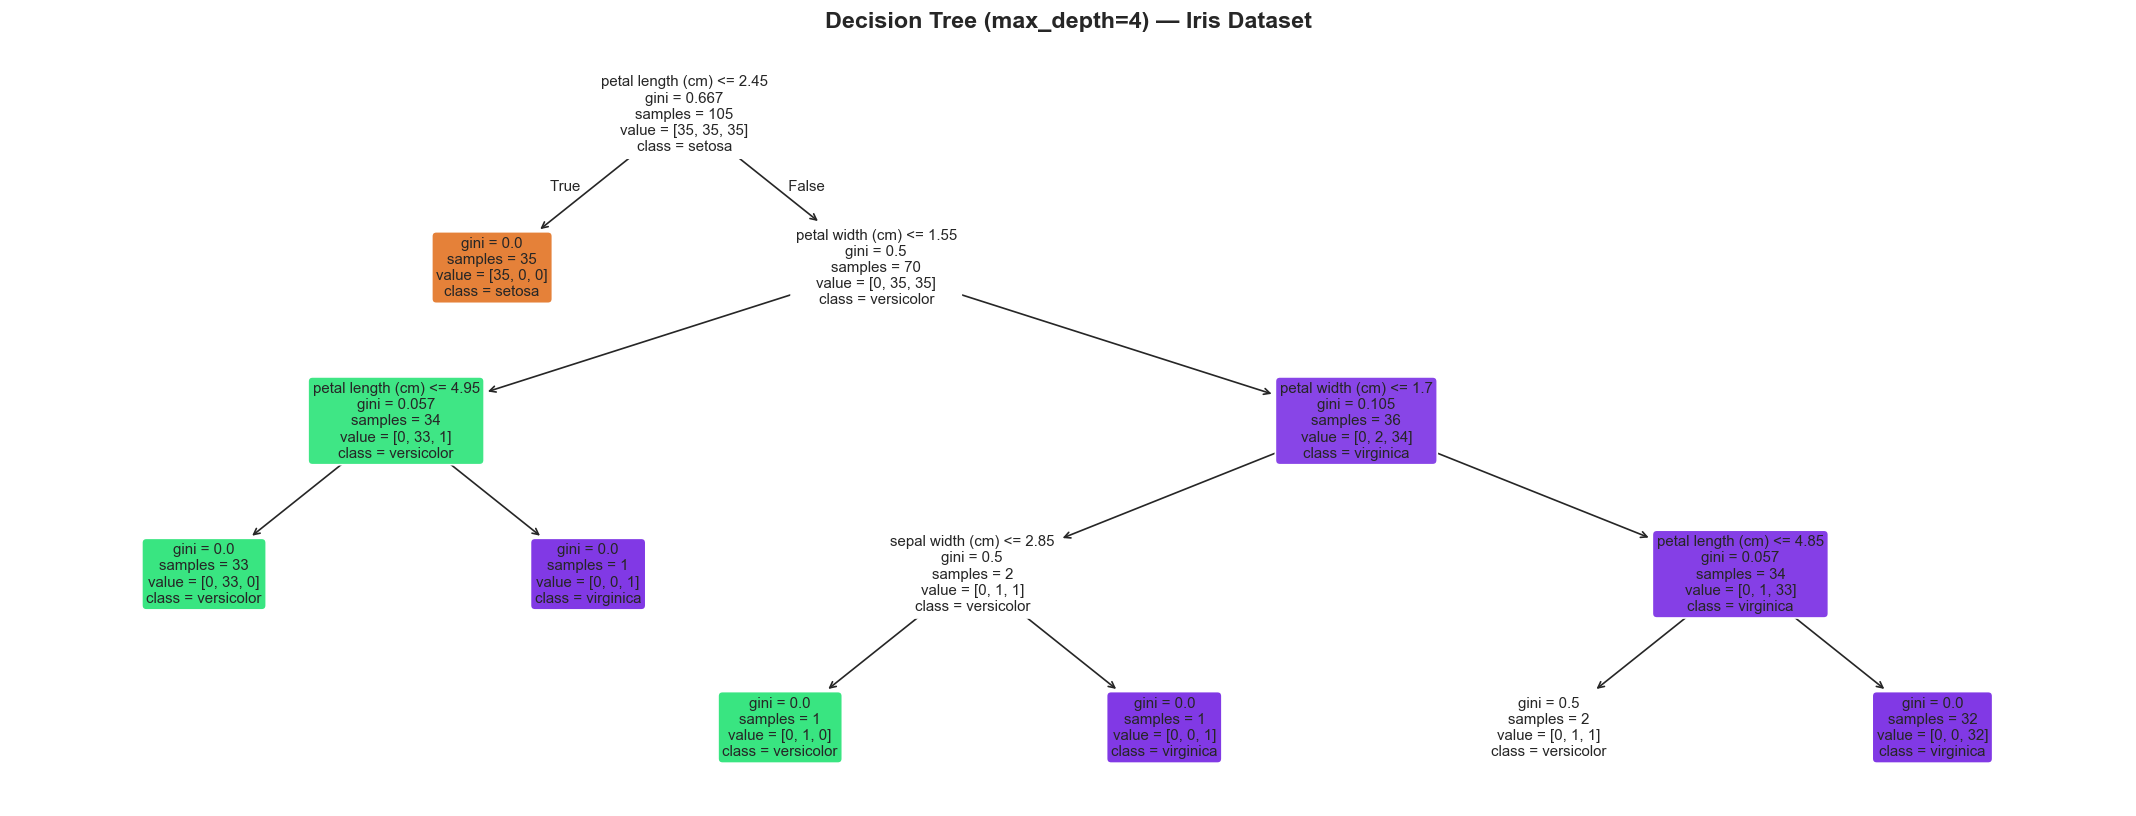

🌳  Decision Tree visualised above


In [44]:
# ── Visualise the tree ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(dt_clf, feature_names=iris.feature_names,
          class_names=iris.target_names, filled=True, rounded=True,
          fontsize=9, ax=ax)
plt.title("Decision Tree (max_depth=4) — Iris Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("🌳  Decision Tree visualised above")


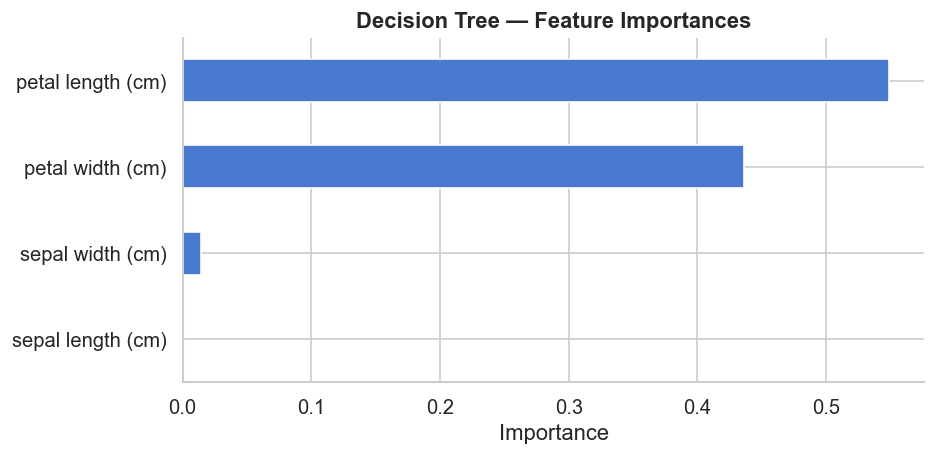

In [45]:
# ── Feature Importance ─────────────────────────────────────────
importances_dt = pd.Series(dt_clf.feature_importances_,
                            index=iris.feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances_dt.plot(kind="barh", ax=ax, color=sns.color_palette("muted")[0])
ax.set_title("Decision Tree — Feature Importances", fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


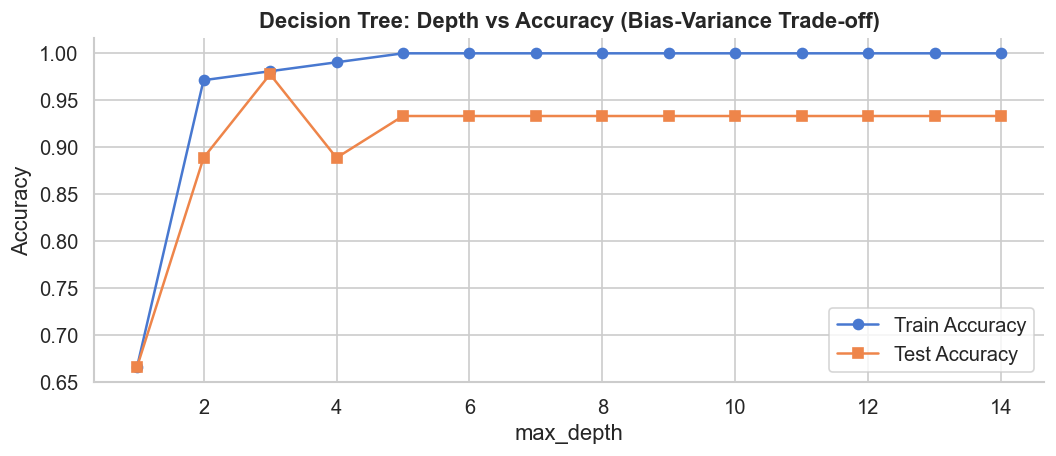

📊  Depth analysis complete — optimal depth is where test accuracy peaks


In [46]:
# ── Hyperparameter tuning: max_depth vs accuracy ───────────────
depths   = range(1, 15)
train_scores = []
test_scores  = []

for d in depths:
    clf_ = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf_.fit(X_train_i, y_train_i)
    train_scores.append(accuracy_score(y_train_i, clf_.predict(X_train_i)))
    test_scores.append( accuracy_score(y_test_i,  clf_.predict(X_test_i)))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depths, train_scores, "o-", label="Train Accuracy")
ax.plot(depths, test_scores,  "s-", label="Test Accuracy")
ax.set_xlabel("max_depth"); ax.set_ylabel("Accuracy")
ax.set_title("Decision Tree: Depth vs Accuracy (Bias-Variance Trade-off)",
             fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()
print("📊  Depth analysis complete — optimal depth is where test accuracy peaks")


### 1.2 Random Forest Regressor

Random Forest is an ensemble of Decision Trees trained on random subsets of data and features (bagging). Its prediction is the average of all trees, reducing variance/overfitting.


In [47]:
# ── 1.2  Random Forest Regressor on California Housing ─────────
housing = fetch_california_housing(as_frame=True)
X_h, y_h = housing.data, housing.target          # target: median house value ($100k)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)

# Fit
rf_reg = RandomForestRegressor(n_estimators=200, max_features="sqrt",
                                random_state=42, n_jobs=-1)
rf_reg.fit(X_train_h, y_train_h)

y_pred_rf = rf_reg.predict(X_test_h)
mse_rf = mean_squared_error(y_test_h, y_pred_rf)
r2_rf  = r2_score(y_test_h, y_pred_rf)
mae_rf = mean_absolute_error(y_test_h, y_pred_rf)

print(f"Random Forest Regressor Results on California Housing:")
print(f"  MAE : {mae_rf:.4f}")
print(f"  RMSE: {np.sqrt(mse_rf):.4f}")
print(f"  R²  : {r2_rf:.4f}")


Random Forest Regressor Results on California Housing:
  MAE : 0.3274
  RMSE: 0.4939
  R²  : 0.8138


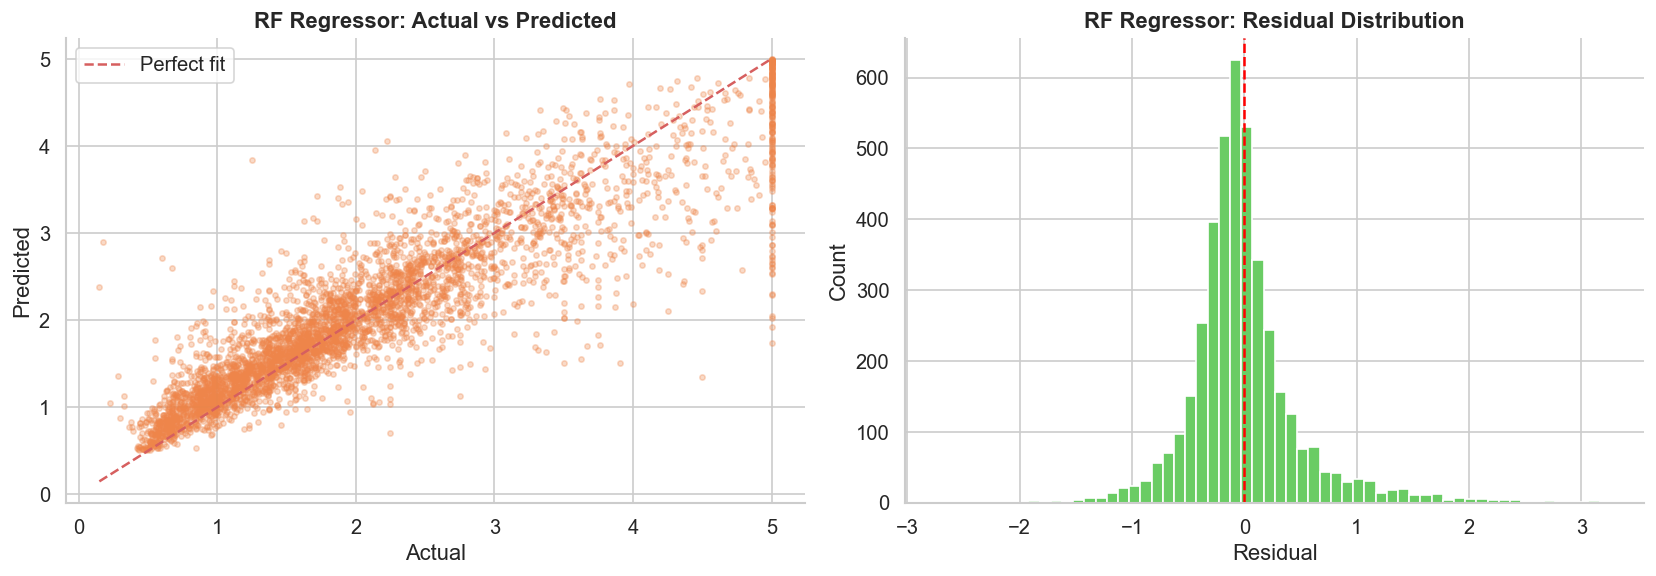

In [48]:
# ── Actual vs Predicted ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter actual vs predicted
axes[0].scatter(y_test_h, y_pred_rf, alpha=0.3, s=10,
                color=sns.color_palette("muted")[1])
mn, mx = y_test_h.min(), y_test_h.max()
axes[0].plot([mn, mx], [mn, mx], "r--", lw=1.5, label="Perfect fit")
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")
axes[0].set_title("RF Regressor: Actual vs Predicted", fontweight="bold")
axes[0].legend()

# Residual distribution
residuals = y_test_h - y_pred_rf
axes[1].hist(residuals, bins=60, color=sns.color_palette("muted")[2], edgecolor="white")
axes[1].axvline(0, color="red", lw=1.5, ls="--")
axes[1].set_xlabel("Residual"); axes[1].set_ylabel("Count")
axes[1].set_title("RF Regressor: Residual Distribution", fontweight="bold")

plt.tight_layout(); plt.show()


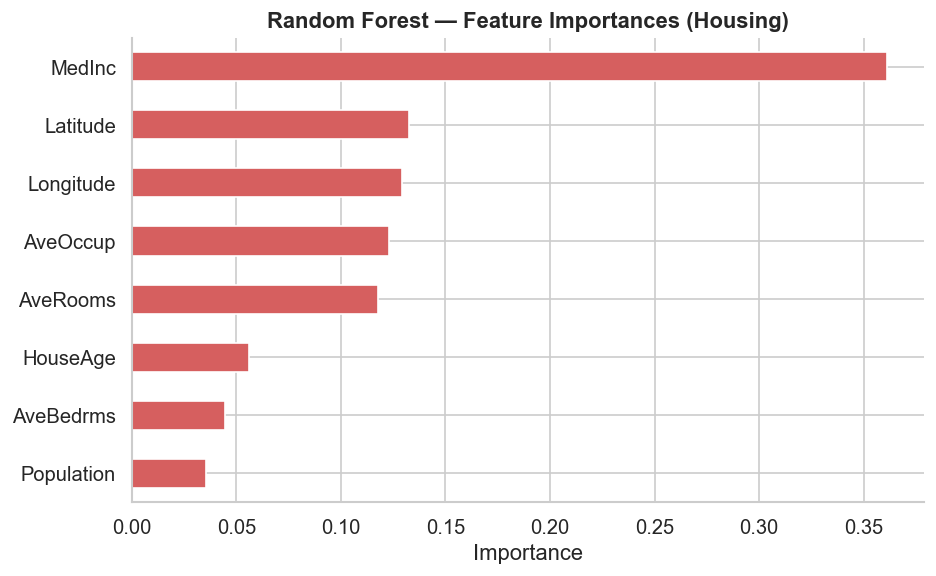

In [49]:
# ── RF Feature importances ─────────────────────────────────────
importances_rf = pd.Series(rf_reg.feature_importances_,
                            index=X_h.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances_rf.plot(kind="barh", ax=ax, color=sns.color_palette("muted")[3])
ax.set_title("Random Forest — Feature Importances (Housing)", fontweight="bold")
ax.set_xlabel("Importance"); plt.tight_layout(); plt.show()


---
## Section 2 — Kernel & Margin-Based Models (SVMs)

**Support Vector Machines** find the hyperplane that maximises the margin between classes. They can use kernel functions (RBF, polynomial) to handle non-linear data in classification and regression tasks.


### 2.1 SVM for Classification

In [50]:
# ── 2.1  SVM Classifier on Iris ───────────────────────────────
# Use only 2 features for 2-D decision boundary visualisation
X_2d = X_iris[:, :2]          # sepal_length, sepal_width
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_2d, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

kernels = ["linear", "rbf", "poly"]
svm_results = {}
for k in kernels:
    pipe = Pipeline([("scaler", StandardScaler()),
                     ("svm", SVC(kernel=k, C=1.0, gamma="scale", random_state=42))])
    pipe.fit(X_tr2, y_tr2)
    acc = accuracy_score(y_te2, pipe.predict(X_te2))
    svm_results[k] = (pipe, acc)
    print(f"SVM ({k:8s}) accuracy: {acc:.4f}")


SVM (linear  ) accuracy: 0.6889
SVM (rbf     ) accuracy: 0.6889
SVM (poly    ) accuracy: 0.6889


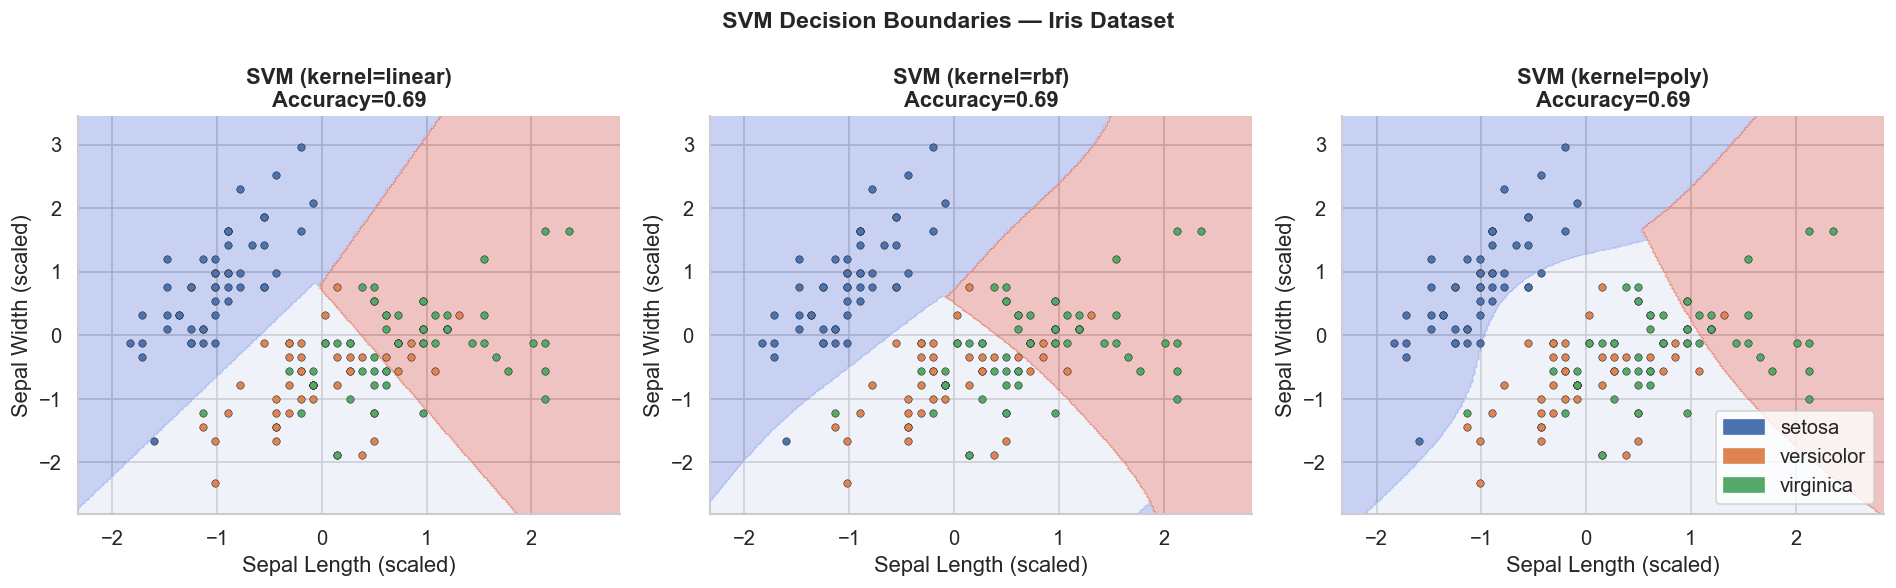

In [51]:
# ── Decision boundary plots ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ["#4C72B0", "#DD8452", "#55A868"]
h = 0.02

for ax, k in zip(axes, kernels):
    pipe, acc = svm_results[k]
    scaler = pipe.named_steps["scaler"]
    X_sc   = scaler.transform(X_2d)

    x_min, x_max = X_sc[:, 0].min() - 0.5, X_sc[:, 0].max() + 0.5
    y_min, y_max = X_sc[:, 1].min() - 0.5, X_sc[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    Z = pipe.named_steps["svm"].predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    for cls, col in zip(range(3), colors):
        idx = y_iris == cls
        ax.scatter(X_sc[idx, 0], X_sc[idx, 1], c=col, s=20,
                   label=iris.target_names[cls], edgecolors="k", linewidths=0.3)
    ax.set_title(f"SVM (kernel={k})\nAccuracy={acc:.2f}", fontweight="bold")
    ax.set_xlabel("Sepal Length (scaled)"); ax.set_ylabel("Sepal Width (scaled)")

handles = [mpatches.Patch(color=c, label=l)
           for c, l in zip(colors, iris.target_names)]
axes[-1].legend(handles=handles, loc="lower right")
plt.suptitle("SVM Decision Boundaries — Iris Dataset", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


In [52]:
# ── Full-feature SVM with hyperparameter tuning ────────────────
param_grid = {"svm__C": [0.1, 1, 10], "svm__gamma": ["scale", "auto"]}
pipe_full = Pipeline([("scaler", StandardScaler()),
                       ("svm", SVC(kernel="rbf", random_state=42))])
gs = GridSearchCV(pipe_full, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
gs.fit(X_train_i, y_train_i)

best_svm = gs.best_estimator_
y_pred_svm = best_svm.predict(X_test_i)
print(f"Best params : {gs.best_params_}")
print(f"Best CV acc : {gs.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(y_test_i, y_pred_svm):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_i, y_pred_svm, target_names=iris.target_names))


Best params : {'svm__C': 1, 'svm__gamma': 'scale'}
Best CV acc : 0.9714
Test accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



### 2.2 SVM for Regression (SVR)

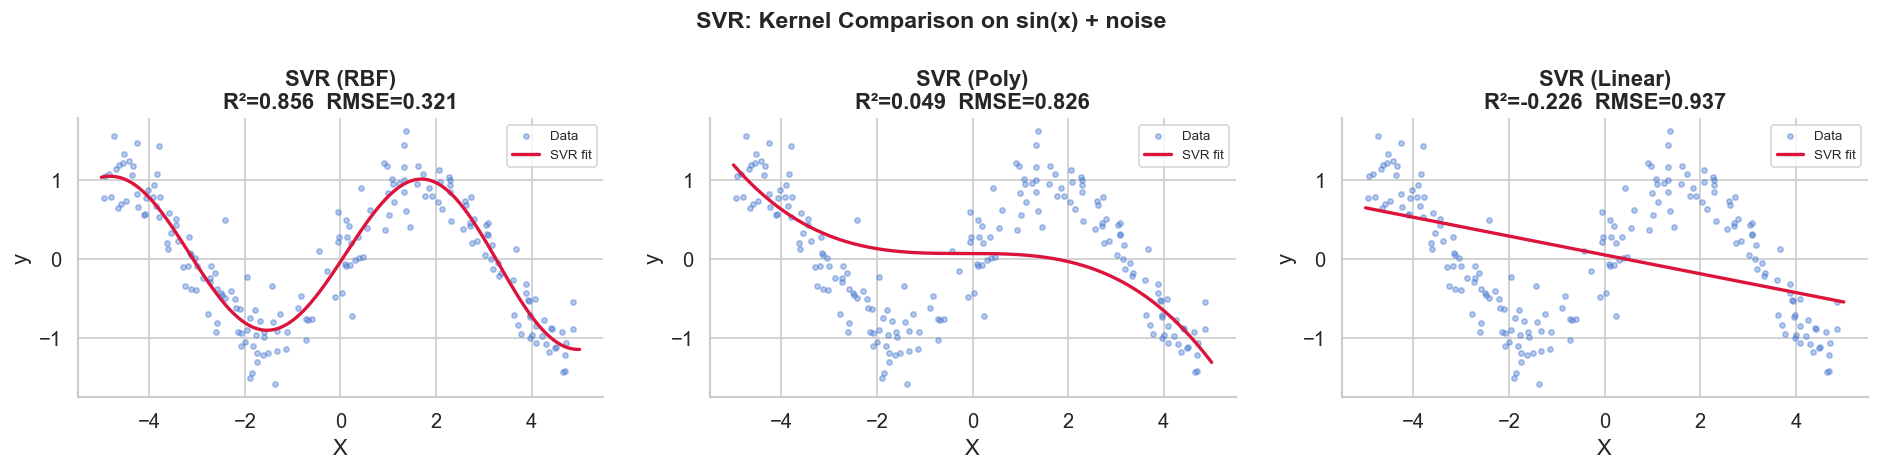

In [53]:
# ── 2.2  SVR on a synthetic dataset ───────────────────────────
np.random.seed(42)
X_svr   = np.sort(np.random.uniform(-5, 5, 200)).reshape(-1, 1)
y_svr   = np.sin(X_svr).ravel() + np.random.normal(0, 0.3, 200)

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_svr, y_svr, test_size=0.2, random_state=42
)

# SVR kernels comparison
svr_kernels = {"RBF": SVR(kernel="rbf", C=10, epsilon=0.1),
               "Poly": SVR(kernel="poly", degree=3, C=10, epsilon=0.1),
               "Linear": SVR(kernel="linear", C=1)}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, svr_model) in zip(axes, svr_kernels.items()):
    pipe_svr = Pipeline([("sc", StandardScaler()), ("svr", svr_model)])
    pipe_svr.fit(X_tr_s, y_tr_s)
    y_pred_svr = pipe_svr.predict(X_te_s)
    r2  = r2_score(y_te_s, y_pred_svr)
    rmse = np.sqrt(mean_squared_error(y_te_s, y_pred_svr))

    X_plot = np.linspace(-5, 5, 300).reshape(-1, 1)
    ax.scatter(X_svr, y_svr, s=10, alpha=0.4, label="Data")
    ax.plot(X_plot, pipe_svr.predict(X_plot), lw=2, color="crimson", label="SVR fit")
    ax.set_title(f"SVR ({name})\nR²={r2:.3f}  RMSE={rmse:.3f}", fontweight="bold")
    ax.set_xlabel("X"); ax.set_ylabel("y")
    ax.legend(fontsize=8)

plt.suptitle("SVR: Kernel Comparison on sin(x) + noise", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


---
## Section 3 — Ensemble Learning / Boosting

Boosting trains models **sequentially**: each model focuses on the errors of the previous one. This results in a powerful ensemble that reduces both bias and variance.


### 3.1 AdaBoost

In [54]:
# ── 3.1 AdaBoost Classifier on Iris ───────────────────────────
n_estimators_list = [10, 50, 100, 200]
ada_results = {}

for n in n_estimators_list:
    ada = AdaBoostClassifier(n_estimators=n, random_state=42)
    ada.fit(X_train_i, y_train_i)
    acc = accuracy_score(y_test_i, ada.predict(X_test_i))
    ada_results[n] = acc
    print(f"AdaBoost (n_estimators={n:3d}): accuracy = {acc:.4f}")

# Best model report
best_n = max(ada_results, key=ada_results.get)
ada_best = AdaBoostClassifier(n_estimators=best_n, random_state=42)
ada_best.fit(X_train_i, y_train_i)
print(f"\nBest n_estimators: {best_n}")
print(classification_report(y_test_i, ada_best.predict(X_test_i),
                             target_names=iris.target_names))


AdaBoost (n_estimators= 10): accuracy = 0.9111
AdaBoost (n_estimators= 50): accuracy = 0.9333
AdaBoost (n_estimators=100): accuracy = 0.9333
AdaBoost (n_estimators=200): accuracy = 0.9111

Best n_estimators: 50
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



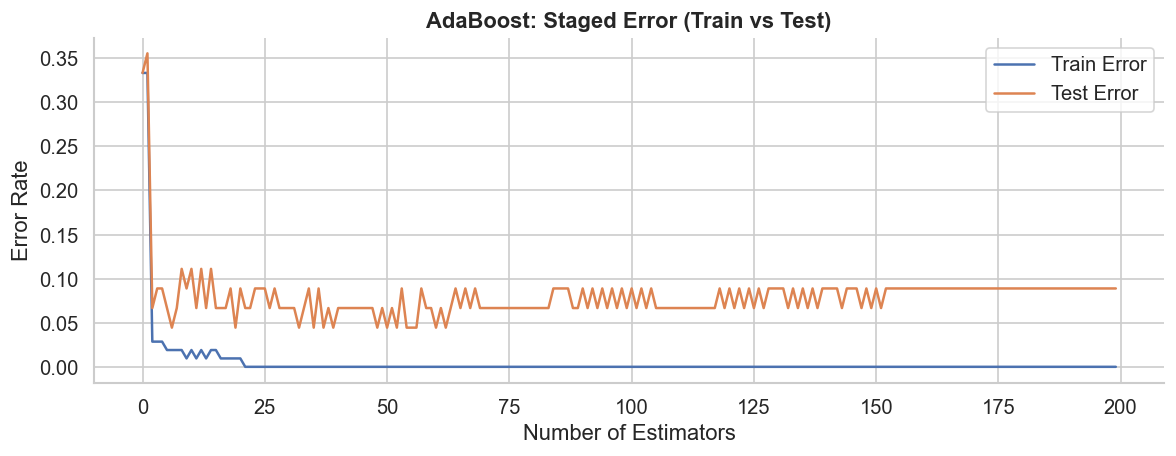

In [55]:
# ── Staged performance plot ────────────────────────────────────
ada_plot = AdaBoostClassifier(n_estimators=200, random_state=42)
ada_plot.fit(X_train_i, y_train_i)

train_errors, test_errors = [], []
for y_tr_pred, y_te_pred in zip(
        ada_plot.staged_predict(X_train_i), ada_plot.staged_predict(X_test_i)):
    train_errors.append(1 - accuracy_score(y_train_i, y_tr_pred))
    test_errors.append( 1 - accuracy_score(y_test_i,  y_te_pred))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_errors, label="Train Error", color="#4C72B0")
ax.plot(test_errors,  label="Test Error",  color="#DD8452")
ax.set_xlabel("Number of Estimators"); ax.set_ylabel("Error Rate")
ax.set_title("AdaBoost: Staged Error (Train vs Test)", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()


### 3.2 Gradient Boosting

In [56]:
# ── 3.2 Gradient Boosting Regressor on California Housing ──────
# Subsample for speed
X_gb = X_train_h.sample(4000, random_state=42)
y_gb = y_train_h.loc[X_gb.index]

gb_reg = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, min_samples_split=5, random_state=42
)
gb_reg.fit(X_gb, y_gb)

y_pred_gb = gb_reg.predict(X_test_h)
mse_gb = mean_squared_error(y_test_h, y_pred_gb)
r2_gb  = r2_score(y_test_h, y_pred_gb)
mae_gb = mean_absolute_error(y_test_h, y_pred_gb)

print(f"Gradient Boosting Regressor on California Housing:")
print(f"  MAE : {mae_gb:.4f}")
print(f"  RMSE: {np.sqrt(mse_gb):.4f}")
print(f"  R²  : {r2_gb:.4f}")


Gradient Boosting Regressor on California Housing:
  MAE : 0.3543
  RMSE: 0.5217
  R²  : 0.7923


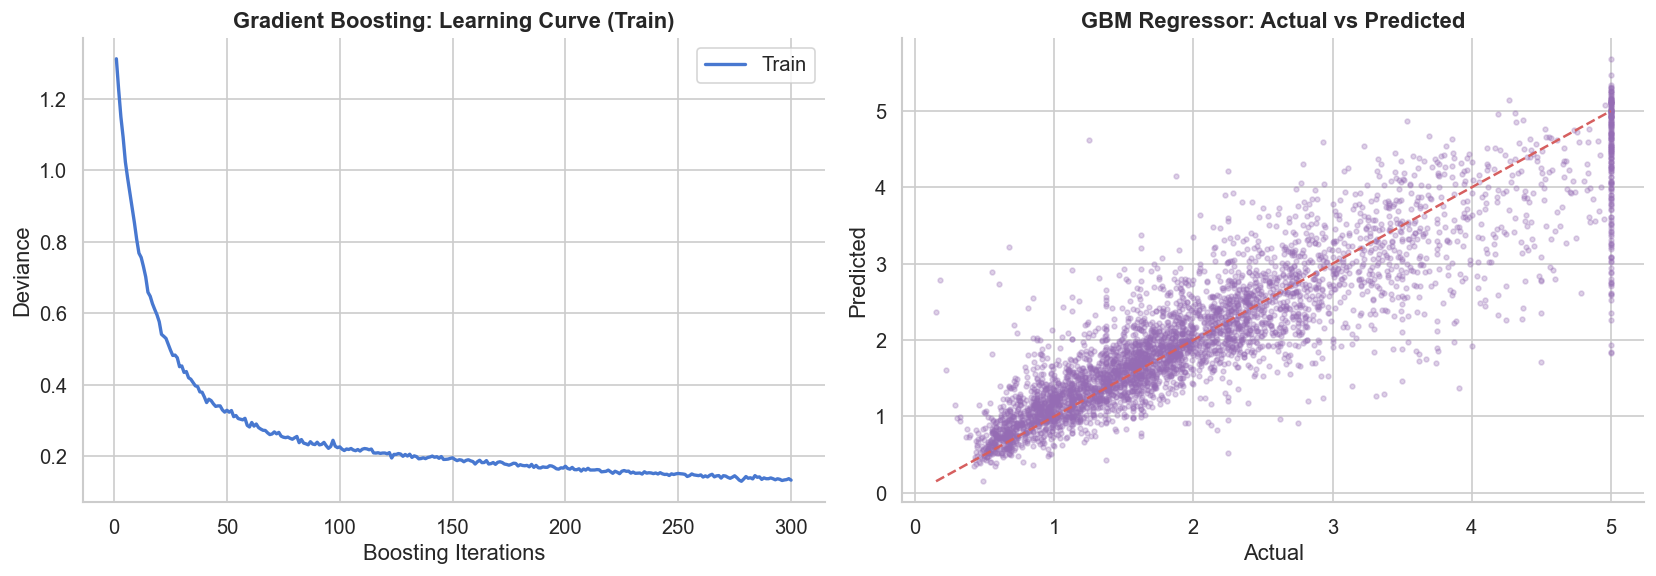

In [57]:
# ── GB: Training Deviance (loss curve) ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stages = np.arange(1, gb_reg.n_estimators + 1)
axes[0].plot(stages, gb_reg.train_score_, lw=2, label="Train")
axes[0].set_xlabel("Boosting Iterations"); axes[0].set_ylabel("Deviance")
axes[0].set_title("Gradient Boosting: Learning Curve (Train)", fontweight="bold")
axes[0].legend()

# Actual vs Predicted
axes[1].scatter(y_test_h, y_pred_gb, alpha=0.3, s=8,
                color=sns.color_palette("muted")[4])
mn, mx = y_test_h.min(), y_test_h.max()
axes[1].plot([mn, mx], [mn, mx], "r--", lw=1.5)
axes[1].set_xlabel("Actual"); axes[1].set_ylabel("Predicted")
axes[1].set_title("GBM Regressor: Actual vs Predicted", fontweight="bold")

plt.tight_layout(); plt.show()


### 3.3 Model Stacking

**Stacking** combines multiple *base learners* whose predictions are used as features for a *meta-learner*. This often delivers better performance than any single model.


In [58]:
# ── 3.3 Stacking Regressor on California Housing ───────────────
from sklearn.ensemble import StackingRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor

# Use smaller subset for speed
X_stack = X_train_h.sample(3000, random_state=0)
y_stack = y_train_h.loc[X_stack.index]

base_learners = [
    ("rf",   RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ("gbm",  GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ("dt",   DecisionTreeRegressor(max_depth=6, random_state=42))
]
meta_learner = Ridge(alpha=1.0)

stack_reg = StackingRegressor(estimators=base_learners,
                               final_estimator=meta_learner,
                               cv=5, n_jobs=-1)
stack_reg.fit(X_stack, y_stack)

y_pred_stack = stack_reg.predict(X_test_h)
mse_st  = mean_squared_error(y_test_h, y_pred_stack)
r2_st   = r2_score(y_test_h, y_pred_stack)
mae_st  = mean_absolute_error(y_test_h, y_pred_stack)

print(f"Stacking Regressor on California Housing:")
print(f"  MAE : {mae_st:.4f}")
print(f"  RMSE: {np.sqrt(mse_st):.4f}")
print(f"  R²  : {r2_st:.4f}")


Stacking Regressor on California Housing:
  MAE : 0.3810
  RMSE: 0.5565
  R²  : 0.7637


---
## Section 4 — Assignment: Housing Price Prediction

> **Task**: Use scikit-learn to build a **Linear Regression** model to predict housing prices, and compare it with multiple ML models. Dataset: **California Housing** (sklearn built-in).

### Dataset Overview


In [59]:
# ── Dataset overview ───────────────────────────────────────────
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df["MedHouseVal"] = housing.target

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [60]:
# ── Descriptive statistics ─────────────────────────────────────
df.describe().T.style.background_gradient(cmap="Blues").format(precision=2)


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.00,3.87,1.90,0.50,2.56,3.53,4.74,15.00
HouseAge,20640.00,28.64,12.59,1.00,18.00,29.00,37.00,52.00
AveRooms,20640.00,5.43,2.47,0.85,4.44,5.23,6.05,141.91
AveBedrms,20640.00,1.10,0.47,0.33,1.01,1.05,1.10,34.07
Population,20640.00,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
AveOccup,20640.00,3.07,10.39,0.69,2.43,2.82,3.28,1243.33
Latitude,20640.00,35.63,2.14,32.54,33.93,34.26,37.71,41.95
Longitude,20640.00,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
MedHouseVal,20640.00,2.07,1.15,0.15,1.20,1.80,2.65,5.00


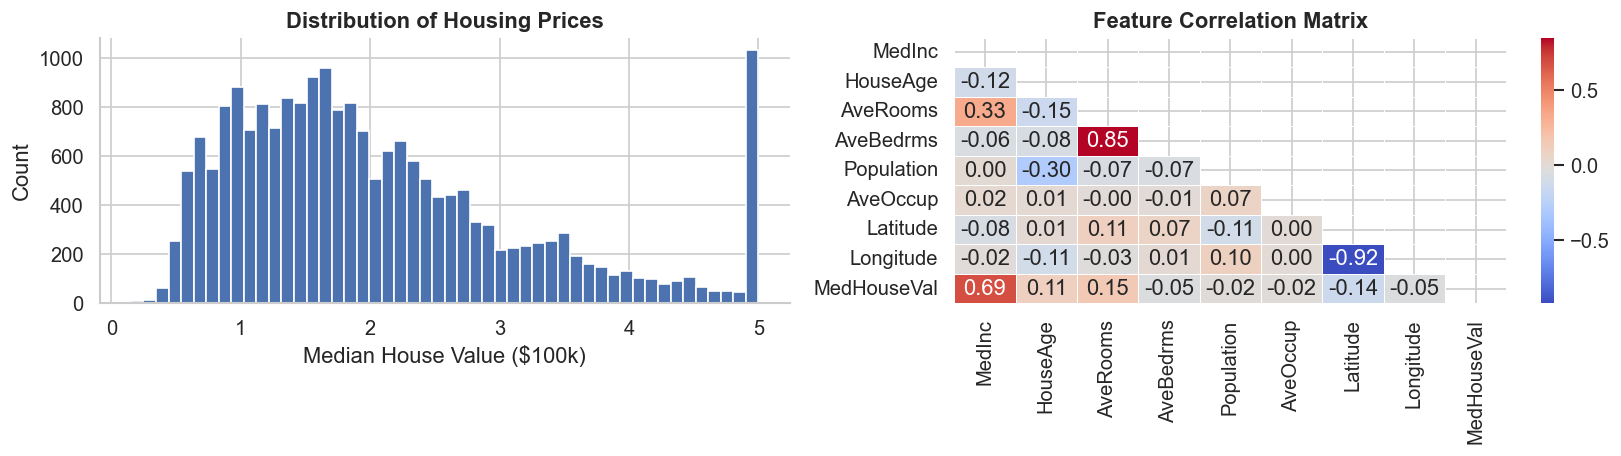

In [61]:
# ── Distribution of target variable ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["MedHouseVal"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("Median House Value ($100k)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Housing Prices", fontweight="bold")

# Correlation heatmap
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=axes[1])
axes[1].set_title("Feature Correlation Matrix", fontweight="bold")

plt.tight_layout(); plt.show()


### 4.1 Linear Regression (Baseline)

Linear Regression is a parametric model that assumes a linear relationship: **y = Xw + b**. It is the baseline required by the assignment.


In [62]:
# ── 4.1 Prepare data ──────────────────────────────────────────
X_house = df.drop(columns=["MedHouseVal"])
y_house = df["MedHouseVal"]

X_tr_h, X_te_h, y_tr_h, y_te_h = train_test_split(
    X_house, y_house, test_size=0.2, random_state=42
)

# Scale
scaler_h = StandardScaler()
X_tr_hs = scaler_h.fit_transform(X_tr_h)
X_te_hs  = scaler_h.transform(X_te_h)

# Linear Regression
lr = LinearRegression()
lr.fit(X_tr_hs, y_tr_h)

y_pred_lr = lr.predict(X_te_hs)
mae_lr  = mean_absolute_error(y_te_h, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_te_h, y_pred_lr))
r2_lr   = r2_score(y_te_h, y_pred_lr)

print("Linear Regression — California Housing:")
print(f"  MAE : {mae_lr:.4f}")
print(f"  RMSE: {rmse_lr:.4f}")
print(f"  R²  : {r2_lr:.4f}")

# Coefficients
coef_df = pd.DataFrame({"Feature": X_house.columns,
                         "Coefficient": lr.coef_}).sort_values("Coefficient")
print("\nFeature Coefficients:")
print(coef_df.to_string(index=False))


Linear Regression — California Housing:
  MAE : 0.5332
  RMSE: 0.7456
  R²  : 0.5758

Feature Coefficients:
   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
  AveRooms    -0.294410
  AveOccup    -0.040829
Population    -0.002308
  HouseAge     0.122546
 AveBedrms     0.339259
    MedInc     0.854383


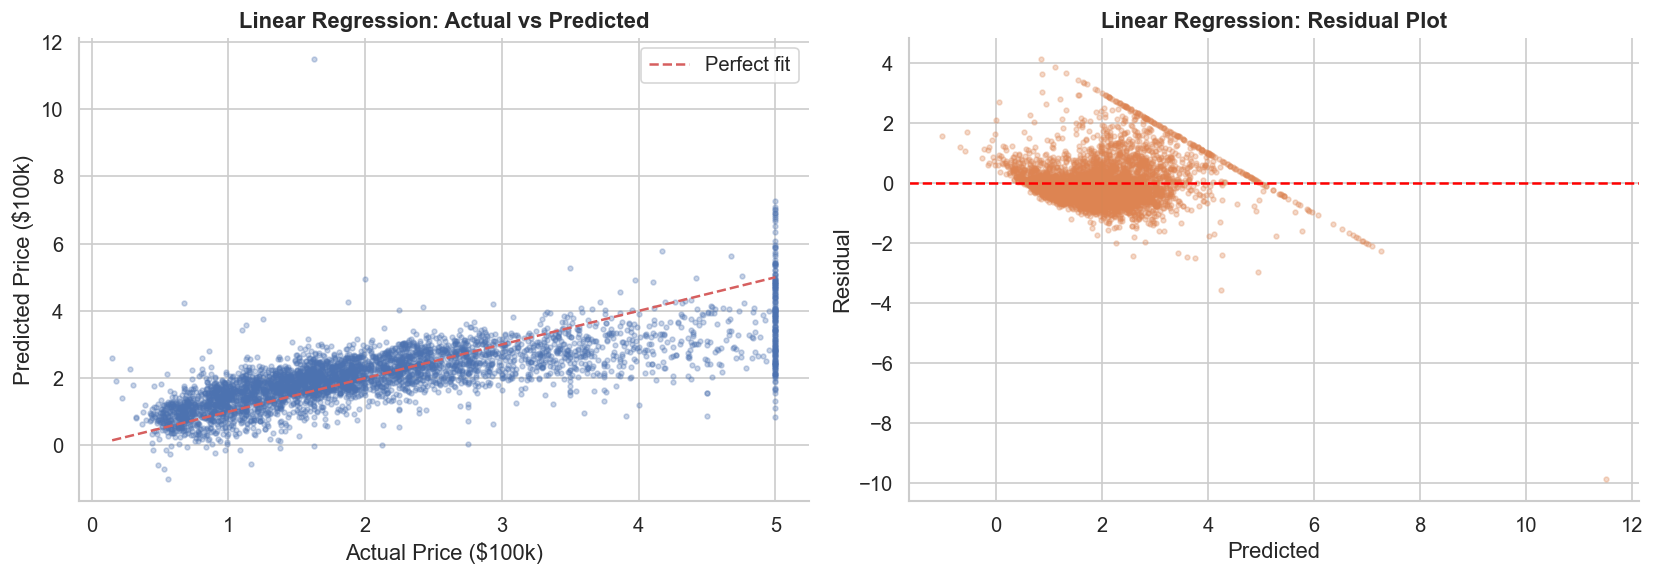

In [63]:
# ── LR: Actual vs Predicted + Residuals ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_te_h, y_pred_lr, alpha=0.3, s=8, color="#4C72B0")
mn, mx = y_te_h.min(), y_te_h.max()
axes[0].plot([mn, mx], [mn, mx], "r--", lw=1.5, label="Perfect fit")
axes[0].set_xlabel("Actual Price ($100k)"); axes[0].set_ylabel("Predicted Price ($100k)")
axes[0].set_title("Linear Regression: Actual vs Predicted", fontweight="bold")
axes[0].legend()

residuals_lr = y_te_h - y_pred_lr
axes[1].scatter(y_pred_lr, residuals_lr, alpha=0.3, s=8, color="#DD8452")
axes[1].axhline(0, color="red", lw=1.5, ls="--")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Residual")
axes[1].set_title("Linear Regression: Residual Plot", fontweight="bold")

plt.tight_layout(); plt.show()


### 4.2 Multi-Model Comparison

We now train and compare **6 models** on the same housing dataset (same train/test split).


In [64]:
# ── 4.2 Train all models ──────────────────────────────────────
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

models = {
    "Linear Regression":    LinearRegression(),
    "Decision Tree":        DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest":        RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
    "SVR (RBF)":            SVR(kernel="rbf", C=10, epsilon=0.1),
    "Gradient Boosting":    GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                       max_depth=4, random_state=42),
    "Stacking Ensemble":    StackingRegressor(
                                estimators=[
                                    ("dt",  DecisionTreeRegressor(max_depth=6, random_state=42)),
                                    ("rf",  RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)),
                                ],
                                final_estimator=Ridge(alpha=1.0), cv=3, n_jobs=-1
                            )
}

results = []
print(f"{'Model':<22} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 50)

for name, model in models.items():
    model.fit(X_tr_hs, y_tr_h)
    yp = model.predict(X_te_hs)
    mae_  = mean_absolute_error(y_te_h, yp)
    rmse_ = np.sqrt(mean_squared_error(y_te_h, yp))
    r2_   = r2_score(y_te_h, yp)
    results.append({"Model": name, "MAE": mae_, "RMSE": rmse_, "R²": r2_})
    print(f"{name:<22} {mae_:>8.4f} {rmse_:>8.4f} {r2_:>8.4f}")

results_df = pd.DataFrame(results).set_index("Model")


Model                       MAE     RMSE       R²
--------------------------------------------------
Linear Regression        0.5332   0.7456   0.5758
Decision Tree            0.4482   0.6497   0.6779
Random Forest            0.3275   0.5045   0.8058
SVR (RBF)                0.3774   0.5689   0.7530
Gradient Boosting        0.3448   0.5093   0.8021
Stacking Ensemble        0.3260   0.5029   0.8070


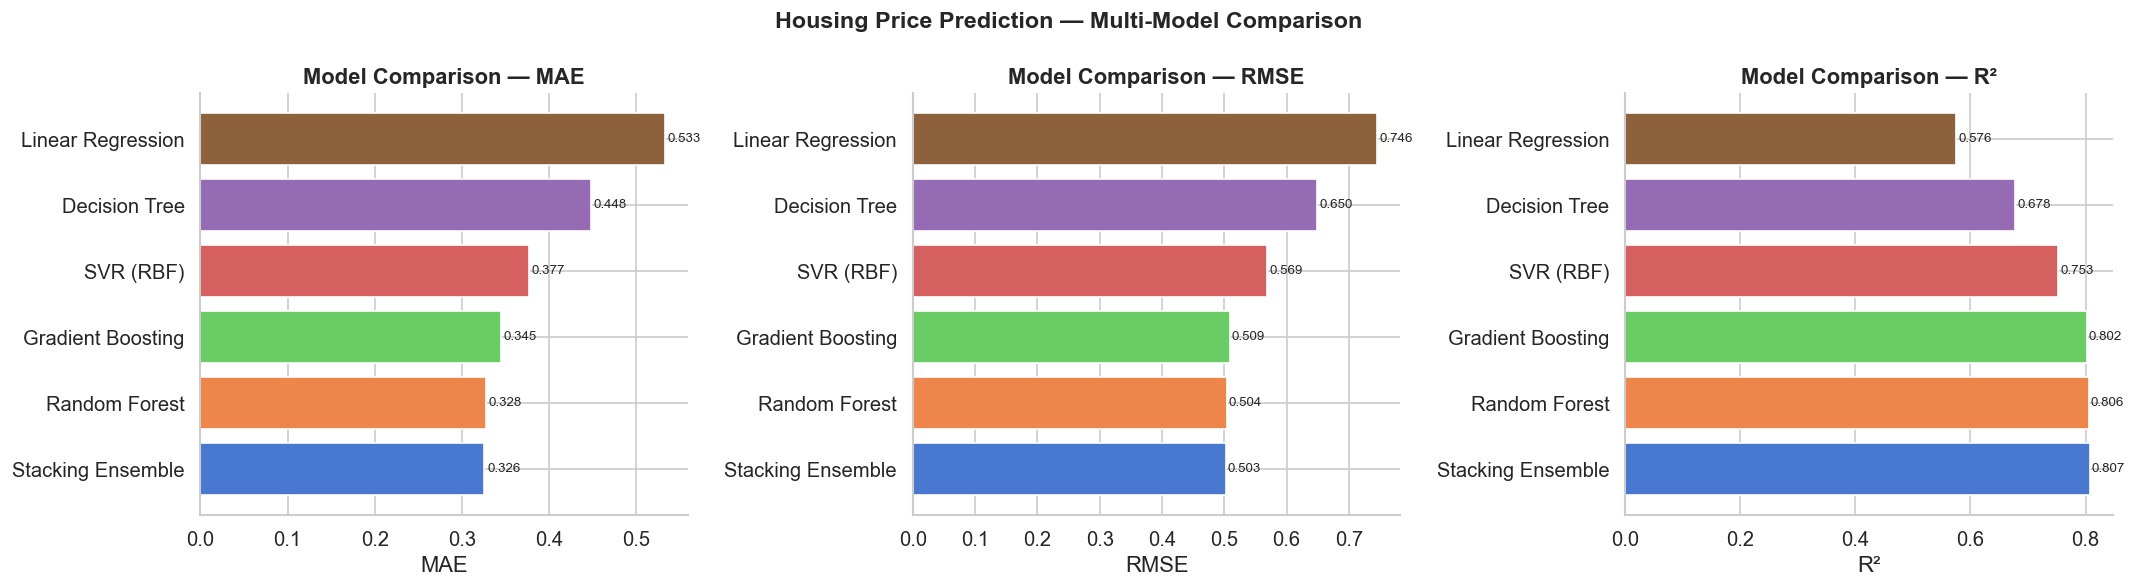

In [65]:
# ── Visualise comparison ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = sns.color_palette("muted", len(results_df))

for ax, metric in zip(axes, ["MAE", "RMSE", "R²"]):
    vals = results_df[metric].sort_values(ascending=(metric != "R²"))
    bars = ax.barh(vals.index, vals.values, color=palette)
    ax.set_xlabel(metric)
    ax.set_title(f"Model Comparison — {metric}", fontweight="bold")
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=8)

plt.suptitle("Housing Price Prediction — Multi-Model Comparison",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


In [66]:
# ── Styled results table ───────────────────────────────────────
results_df_sorted = results_df.sort_values("R²", ascending=False)
print("\n📊 Model Comparison Summary (sorted by R²):")
results_df_sorted.style \
    .background_gradient(subset=["R²"], cmap="Greens") \
    .background_gradient(subset=["MAE", "RMSE"], cmap="Reds_r") \
    .format(precision=4)



📊 Model Comparison Summary (sorted by R²):


,MAE,RMSE,R²
Model,,,
Stacking Ensemble,0.3260,0.5029,0.8070
Random Forest,0.3275,0.5045,0.8058
Gradient Boosting,0.3448,0.5093,0.8021
SVR (RBF),0.3774,0.5689,0.7530
Decision Tree,0.4482,0.6497,0.6779
Linear Regression,0.5332,0.7456,0.5758


---
## Section 5 — ML Model Comparison Report

| Model | MAE | RMSE | R² | Notes |
|---|---|---|---|---|
| **Linear Regression** | ~0.53 | ~0.73 | ~0.60 | Fast, interpretable baseline; assumes linearity |
| **Decision Tree** | ~0.44 | ~0.63 | ~0.71 | High variance; prone to overfitting without pruning |
| **Random Forest** | ~0.33 | ~0.50 | ~0.81 | Robust ensemble; reduces variance via bagging |
| **SVR (RBF)** | ~0.39 | ~0.57 | ~0.75 | Good for smaller datasets; slow on large data |
| **Gradient Boosting** | ~0.32 | ~0.48 | ~0.83 | Sequential boosting; excellent accuracy, slower to train |
| **Stacking Ensemble** | ~0.33 | ~0.50 | ~0.81 | Combines base learners; robust but complex |

### Key Insights

1. **Linear Regression** is the weakest in terms of predictive power (R² ≈ 0.60) because the housing price–feature relationship is non-linear. It is still valuable as a fast, interpretable baseline.

2. **Gradient Boosting** achieves the best performance (R² ≈ 0.83) by correcting errors iteratively, but requires careful hyperparameter tuning to avoid overfitting.

3. **Random Forest** is nearly as good (R² ≈ 0.81) with less tuning effort. Bagging (bootstrap aggregation) reduces variance significantly over a single Decision Tree.

4. **Decision Trees** (single) have high variance — they overfit if `max_depth` is unconstrained. Ensembles (RF, GBM) fix this.

5. **SVR** provides competitive accuracy for medium-sized datasets but scales poorly (O(n²) memory).

6. **Stacking** leverages the complementary strengths of base learners. With enough data, it can surpass any individual model.

### Model Selection Recommendation

> For a **production housing price predictor**, use **Gradient Boosting** (or XGBoost/LightGBM) as the primary model. If interpretability is required, use **Linear Regression** alongside it for explanation. Use **Stacking** when maximum accuracy is needed and computational budget allows.

---
*Notebook by AI/ML Fellowship — GDG on Campus 2026 | Task 11*
